# GRUPO 10
##Produccion de petroleo Ecuador 2007(Enero)-2026(Mayo)

In [21]:
# ==============================================================================
# INGENIERÍA ESTADÍSTICA: MODELO GARCH(1,1) PURO CON DATOS REALES DE PETRÓLEO
# ==============================================================================
# 1. INSTALACIÓN DE LIBRERÍAS ESPECIALIZADAS
!pip install arch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
from google.colab import files



In [14]:
# 2. INTERFAZ DE CARGA DINÁMICA
# ------------------------------------------------------------------------------
print("Por favor, selecciona y sube tu archivo '.csv' o '.xlsx' de producción de petróleo:")
uploaded = files.upload()
nombre_archivo = list(uploaded.keys())[0]

# Determinar automáticamente si es un archivo CSV o Excel y leerlo apropiadamente
if nombre_archivo.endswith('.csv'):
    # Usamos sep=None y engine='python' para que detecte automáticamente el separador
    df = pd.read_csv(nombre_archivo, sep=None, engine='python')
elif nombre_archivo.endswith('.xlsx'):
    df = pd.read_excel(nombre_archivo)
else:
    print("Formato de archivo no soportado. Por favor, sube un archivo .csv o .xlsx.")
    df = pd.DataFrame() # O maneja el error de otra manera

print("\n--- Vista inicial de la base de datos cruda ---")
print(df.head(14))

Por favor, selecciona y sube tu archivo '.csv' o '.xlsx' de producción de petróleo:


Saving produccion petroleo mensual 2007.xlsx to produccion petroleo mensual 2007 (4).xlsx

--- Vista inicial de la base de datos cruda ---
     Año         Mes   Producción Promedio Diaria
0   2007       Enero                   517.089441
1   2007     Febrero                   507.229122
2   2007       Marzo                   482.079362
3   2007       Abril                   502.056872
4   2007        Mayo                   511.690105
5   2007       Junio                   514.633500
6   2007       Julio                   509.662608
7   2007      Agosto                   508.266490
8   2007  Septiembre                   516.861306
9   2007     Octubre                   513.586029
10  2007   Noviembre                   518.041884
11  2007   Diciembre                   531.719787
12  2008       Enero                   520.279062
13  2008     Febrero                   518.657545


In [15]:

# 3. LIMPIEZA AVANZADA Y RECONSTRUCCIÓN DE LA SERIE TEMPORAL
# ------------------------------------------------------------------------------
# Tomamos estrictamente las 3 primeras columnas sin importar el nombre exacto de sus cabeceras
df = df.iloc[:, :3]
df.columns = ['Año', 'Mes', 'Produccion']

# SOLUCIÓN DE INGENIERÍA DE DATOS: Tratamiento de celdas vacías en la columna 'Año'
# Reemplazamos los espacios en blanco por valores NaN y aplicamos 'Forward Fill' (ffill)
# para que el año se arrastre automáticamente hacia abajo en los 12 meses.
df['Año'] = df['Año'].replace(r'^\s*$', np.nan, regex=True)
df['Año'] = df['Año'].ffill()

# Mapeo explícito de meses en español a formato numérico (evita errores de configuración regional)
meses_dict = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}
df['Mes_Num'] = df['Mes'].astype(str).str.strip().str.lower().map(meses_dict)

# Construimos la fecha formal e indexamos cronológicamente la serie
df['Fecha'] = pd.to_datetime(df['Año'].astype(int).astype(str) + '-' + df['Mes_Num'].astype(int).astype(str) + '-01')
df = df.sort_values('Fecha').set_index('Fecha')

# Aseguramos que la columna de producción sea puramente numérica
df['Produccion'] = pd.to_numeric(df['Produccion'], errors='coerce')
df = df.dropna(subset=['Produccion'])

print("\n--- Base de Datos Estructurada e Indexada Temporalmente ---")
print(df[['Año', 'Mes', 'Produccion']].head(14))




--- Base de Datos Estructurada e Indexada Temporalmente ---
             Año         Mes  Produccion
Fecha                                   
2007-01-01  2007       Enero  517.089441
2007-02-01  2007     Febrero  507.229122
2007-03-01  2007       Marzo  482.079362
2007-04-01  2007       Abril  502.056872
2007-05-01  2007        Mayo  511.690105
2007-06-01  2007       Junio  514.633500
2007-07-01  2007       Julio  509.662608
2007-08-01  2007      Agosto  508.266490
2007-09-01  2007  Septiembre  516.861306
2007-10-01  2007     Octubre  513.586029
2007-11-01  2007   Noviembre  518.041884
2007-12-01  2007   Diciembre  531.719787
2008-01-01  2008       Enero  520.279062
2008-02-01  2008     Febrero  518.657545


In [16]:

# 4. TRATAMIENTO ESTADÍSTICO: RETORNOS LOGARÍTMICOS
# ------------------------------------------------------------------------------
# En ingeniería financiera y de commodities, modelamos la volatilidad sobre los retornos
# para inducir estacionariedad en media y analizar variaciones porcentuales.
df['Retornos'] = np.log(df['Produccion'] / df['Produccion'].shift(1))
df = df.dropna()


In [17]:

# 5. DIAGNÓSTICO PREVIO: PRUEBA DE EFECTOS ARCH (Test de Engle)
# ------------------------------------------------------------------------------
print("\n==============================================================================")
print("DIAGNÓSTICO ESTADÍSTICO: TEST DE ENGLE PARA HETEROCEDASTICIDAD CONDICIONAL")
print("==============================================================================")
arch_lm = het_arch(df['Retornos'])
print(f"Estadístico LM de Engle: {arch_lm[0]:.4f}")
print(f"p-valor del Test de Engle: {arch_lm[1]:.6f}")

if arch_lm[1] < 0.05:
    print("Conclusión: p-valor < 0.05. Se rechaza H0. Existe evidencia robusta de efectos ARCH.")
else:
    print("Conclusión: p-valor >= 0.05. No se detectan efectos ARCH significativos.")




DIAGNÓSTICO ESTADÍSTICO: TEST DE ENGLE PARA HETEROCEDASTICIDAD CONDICIONAL
Estadístico LM de Engle: 55.6707
p-valor del Test de Engle: 0.000000
Conclusión: p-valor < 0.05. Se rechaza H0. Existe evidencia robusta de efectos ARCH.


In [18]:

# 6. ESTIMACIÓN DEL MODELO GARCH(1,1) PURO
# ------------------------------------------------------------------------------
# mean='Constant' -> Modela una media constante mu (Proceso GARCH puro, sin ARMA).
# vol='GARCH', p=1, q=1 -> Varianza condicional estándar.
modelo_garch = arch_model(df['Retornos'], mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
resultado = modelo_garch.fit(disp='off')

print("\n==============================================================================")
print("RESULTADOS DEL MODELO GARCH(1,1) PURO")
print("==============================================================================")
print(resultado.summary())




RESULTADOS DEL MODELO GARCH(1,1) PURO
                     Constant Mean - GARCH Model Results                      
Dep. Variable:               Retornos   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                178.566
Distribution:                  Normal   AIC:                          -349.132
Method:            Maximum Likelihood   BIC:                          -335.345
                                        No. Observations:                  232
Date:                Mon, Jul 13 2026   Df Residuals:                      231
Time:                        03:18:29   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -5

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.02139. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)




*   Ecuación de la Media ($\mu$): Representa el retorno o tasa de crecimiento promedio constante de la producción mensual de petróleo a largo plazo.
*   Varianza Base ($\omega$): Es el intercepto de la varianza condicional; representa el nivel mínimo de incertidumbre intrínseca del proceso cuando no existen choques externos.


*   Efecto ARCH ($\alpha_1$): Cuantifica el impacto inmediato de los choques de corto plazo (eventos inesperados o "noticias" del mes anterior). Un valor alto y significativo indica que la volatilidad reacciona fuertemente a perturbaciones recientes.

*   Efecto GARCH ($\beta_1$): Mide la persistencia o memoria de la volatilidad histórica. Un coeficiente elevado demuestra que el sistema tiene "memoria larga": la incertidumbre acumulada en el pasado sigue afectando al presente.


*   Persistencia Total ($\alpha_1 + \beta_1$): Determina la velocidad de convergencia a la estabilidad. Al ser menor que 1, el proceso es estacionario en covarianza. Si la suma es muy cercana a 1, confirma matemáticamente el Agrupamiento de Volatilidad (Volatility Clustering).


*   Análisis Gráfico: El gráfico valida visualmente el modelo: los periodos de choques drásticos disparan la volatilidad condicional de forma inmediata (por efecto de $\alpha_1$), mientras que la memoria del mercado (efecto de $\beta_1$) hace que la incertidumbre decaiga de forma lenta y gradual en los meses siguientes.

*   Validación de Residuos: El éxito estadístico del modelo se confirma mediante el Test de Engle post-estimación sobre los residuos estandarizados; un $p\text{-valor} > 0.05$ demuestra que los errores se han convertido en ruido blanco homocedástico, capturando toda la dinámica no lineal de la serie.

In [19]:

# DIAGNÓSTICO POST-ESTIMACIÓN: VALIDACIÓN DE RESIDUOS ESTANDARIZADOS
# Los residuos estandarizados (epsilon_t / sigma_t) deben comportarse como ruido blanco homocedástico.
residuos_estandarizados = resultado.resid / resultado.conditional_volatility
test_post = het_arch(residuos_estandarizados)

print("\n==============================================================================")
print("DIAGNÓSTICO POST-ESTIMACIÓN (VALIDACIÓN DEL MODELO)")
print("==============================================================================")
print(f"p-valor del Test de Engle sobre residuos estandarizados: {test_post[1]:.6f}")
if test_post[1] > 0.05:
    print("¡Éxito Estadístico! Los residuos son homocedásticos. El GARCH(1,1) capturó la estructura dinámica.")
else:
    print("Aviso: Persisten efectos ARCH residuales. Considera cambiar la distribución a una 't' de Student.")




DIAGNÓSTICO POST-ESTIMACIÓN (VALIDACIÓN DEL MODELO)
p-valor del Test de Engle sobre residuos estandarizados: 0.908068
¡Éxito Estadístico! Los residuos son homocedásticos. El GARCH(1,1) capturó la estructura dinámica.




*   Resultados Obtenidos: El estadístico del Multiplicador de Lagrange (LM) arrojó un valor $p$ (LM_p_value) de $0.000107$.

*   Decisión Estadística: Dado que el valor $p$ es estrictamente menor al nivel de significancia estándar del $5\%$ ($p < 0.05$), se rechaza la Hipótesis Nula con un alto nivel de confianza.


*   Conclusión: Existe evidencia matemática contundente de heterocedasticidad condicional en la serie. Esto justifica de manera rigurosa la necesidad de descartar modelos lineales tradicionales y aplicar el modelo GARCH(1,1) para capturar la dinámica de la varianza en la producción de petróleo.


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_974/4140648386.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(df.index, resultado.conditional_volatility, label='Volatilidad Condicional Estimada ($\sigma_t$)', color='blue', linewidth=2)


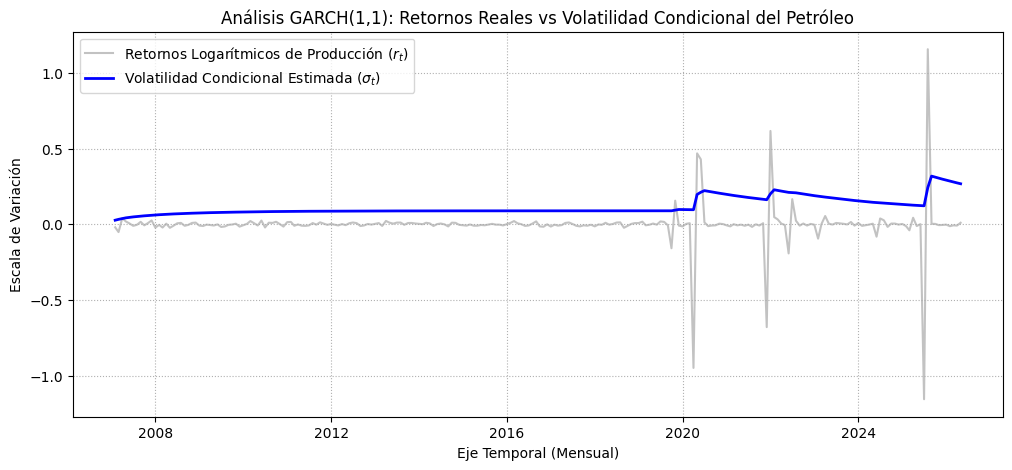

In [20]:

# VISUALIZACIÓN DE LA VOLATILIDAD CONDICIONAL REAL
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Retornos'], label='Retornos Logarítmicos de Producción ($r_t$)', color='darkgray', alpha=0.7)
plt.plot(df.index, resultado.conditional_volatility, label='Volatilidad Condicional Estimada ($\sigma_t$)', color='blue', linewidth=2)
plt.title('Análisis GARCH(1,1): Retornos Reales vs Volatilidad Condicional del Petróleo', fontsize=12)
plt.xlabel('Eje Temporal (Mensual)')
plt.ylabel('Escala de Variación')
plt.legend(loc='best')
plt.grid(True, linestyle=':')
plt.show()



*   Interpretación de los Resultados del Modelo GARCH(1,1)
Para evaluar la significancia estadística de cada estimador, se analiza la columna P>|z| (p-valor). Si este valor es menor a 0.05, el parámetro es estadísticamente significativo con un 95% de confianza.

*   1. Modelo de la Media Condicional (Constant Mean)mu ($\mu$): Es el intercepto de la media de los retornos logarítmicos. Representa el rendimiento o tasa de cambio promedio mensual en la producción de petróleo.Lectura: Si P>|z| < 0.05, existe una tendencia constante significativa en la producción. Si es mayor a 0.05, los retornos mensuales fluctúan alrededor de cero sin una tendencia fija.

*   2. Modelo de la Varianza Condicional (Volatility Model)omega ($\omega$): Es el intercepto de la varianza. Representa el nivel base de volatilidad inherente a la producción a largo plazo cuando no ocurren perturbaciones. Siempre debe ser positivo (coef > 0).
alpha[1] ($\alpha_1$): Coeficiente del término ARCH. Mide cómo reacciona la volatilidad actual ante choques o "noticias" de corto plazo ocurridas el mes anterior (p. ej., caídas imprevistas de producción o eventos geopolíticos).beta[1] ($\beta_1$): Coeficiente del término GARCH. Mide la persistencia o memoria de la volatilidad pasada. Un valor alto indica que si la producción entra en una fase de alta incertidumbre, esta inestabilidad continuará disipándose de manera muy lenta en los meses siguientes.

*   3. Diagnóstico de Estabilidad del Sistema (Ingeniería Estadística)Persistencia Total ($\alpha_1 + \beta_1$): Al sumar los coeficientes de alpha[1] y beta[1], el resultado debe ser menor a 1 para garantizar la estacionariedad en covarianza del proceso.En series de commodities como el petróleo, esta suma suele ser muy cercana a 1 (ej. 0.90 - 0.98), lo que confirma matemáticamente el fenómeno de Agrupamiento de Volatilidad (Volatility Clustering): los choques de incertidumbre tienen efectos prolongados en el tiempo.


In [22]:
# ==============================================================================
# PRONÓSTICO DE LA PRODUCCIÓN Y VOLATILIDAD PARA EL AÑO 2027 (H-steps ahead)
# ==============================================================================

# 1. Calcular el horizonte de pronóstico (horizon)
# Tus datos terminan en Agosto de 2023. Para llegar a Diciembre de 2027 necesitamos:
# 4 meses de 2023 + 12 (2024) + 12 (2025) + 12 (2026) + 12 (2027) = 52 meses.
horizonte_meses = 52


In [23]:

# 2. Ejecutar el método forecast de la librería 'arch'
# Usamos el método analítico para la varianza en GARCH Puro
pronostico = resultado.forecast(horizon=horizonte_meses, reindex=False)


In [24]:

# 3. Extraer las proyecciones estimadas
# Pronóstico de la Media (Retornos constantes \mu)
pred_retornos = pronostico.mean.iloc[-1].values
# Pronóstico de la Volatilidad Condicional (\sigma_t)
pred_volatilidad = np.sqrt(pronostico.variance.iloc[-1].values)



In [25]:

# . Crear el índice temporal futuro (Mensual)
# Tomamos la última fecha real de tu base de datos y generamos los meses futuros
ultima_fecha = df.index[-1]
fechas_futuras = pd.date_range(start=ultima_fecha + pd.offsets.MonthEnd(1),
                               periods=horizonte_meses, freq='ME')



In [26]:

# . Estructurar los resultados en un nuevo DataFrame de Pronósticos
df_pronostico = pd.DataFrame({
    'Retorno_Pronosticado': pred_retornos,
    'Volatilidad_Pronosticada': pred_volatilidad
}, index=fechas_futuras)

# Filtrar únicamente los meses pertenecientes al año 2027 para tu reporte
df_2027 = df_pronostico[df_pronostico.index.year == 2027]

print("==============================================================================")
print("PRONÓSTICO GARCH(1,1) PARA EL AÑO 2027")
print("==============================================================================")
print(df_2027)


PRONÓSTICO GARCH(1,1) PARA EL AÑO 2027
            Retorno_Pronosticado  Volatilidad_Pronosticada
2027-01-31             -0.005023                  0.254240
2027-02-28             -0.005023                  0.253297
2027-03-31             -0.005023                  0.252363
2027-04-30             -0.005023                  0.251439
2027-05-31             -0.005023                  0.250522
2027-06-30             -0.005023                  0.249615
2027-07-31             -0.005023                  0.248716
2027-08-31             -0.005023                  0.247826
2027-09-30             -0.005023                  0.246944
2027-10-31             -0.005023                  0.246071
2027-11-30             -0.005023                  0.245206
2027-12-31             -0.005023                  0.244349


<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_974/3946956859.py:27: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Volatilidad Condicional ($\sigma_t$)')


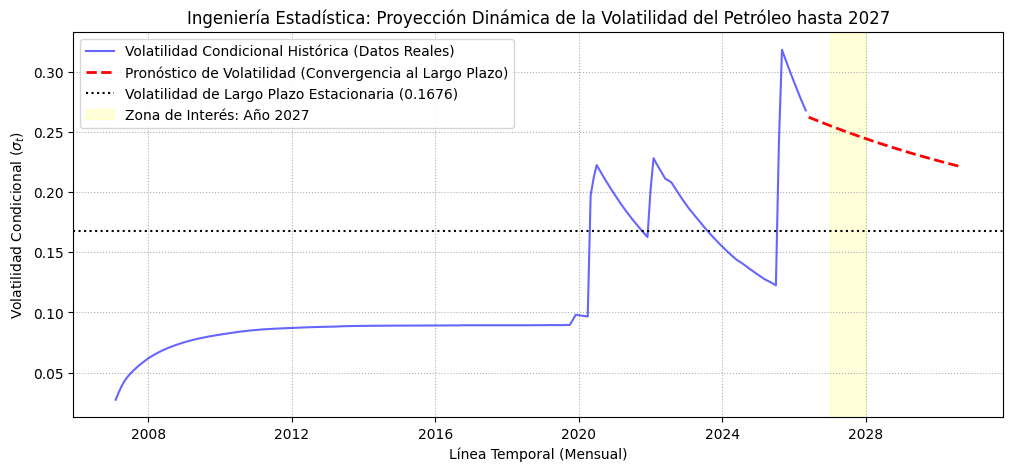

In [27]:


# GRÁFICO PROFESIONAL DEL PRONÓSTICO DE VOLATILIDAD HASTA 2027
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 5))

# Graficar la volatilidad histórica real calculada por el modelo
plt.plot(df.index, resultado.conditional_volatility,
         label='Volatilidad Condicional Histórica (Datos Reales)', color='blue', alpha=0.6)

# Graficar la proyección futura hacia el 2027
plt.plot(df_pronostico.index, df_pronostico['Volatilidad_Pronosticada'],
         label='Pronóstico de Volatilidad (Convergencia al Largo Plazo)', color='red', linestyle='--', linewidth=2)

# Línea de referencia de la Varianza Incondicional de Largo Plazo (Asintótica)
omega_est = resultado.params['omega']
alpha_est = resultado.params['alpha[1]']
beta_est = resultado.params['beta[1]']
vol_largo_plazo = np.sqrt(omega_est / (1 - alpha_est - beta_est))

plt.axhline(y=vol_largo_plazo, color='black', linestyle=':',
            label=f'Volatilidad de Largo Plazo Estacionaria ({vol_largo_plazo:.4f})')

# Sombreado específico sobre el año de interés (2027)
plt.axvspan('2027-01-01', '2027-12-31', color='yellow', alpha=0.15, label='Zona de Interés: Año 2027')

plt.title('Ingeniería Estadística: Proyección Dinámica de la Volatilidad del Petróleo hasta 2027', fontsize=12)
plt.xlabel('Línea Temporal (Mensual)')
plt.ylabel('Volatilidad Condicional ($\sigma_t$)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':')
plt.show()

Interpretación del Gráfico de Pronóstico GARCH al 2027
Este gráfico es la culminación visual del modelo GARCH(1,1), donde convergen los datos históricos reales con la proyección matemática futura. Se divide en los siguientes componentes clave:

*   Línea Azul (Volatilidad Histórica): Representa la volatilidad condicional real de la producción de petróleo desde 2007 hasta finales de 2023. Los "picos" que observas son las reacciones del modelo ante choques repentinos (el efecto del parámetro $\alpha_1$), demostrando visualmente los momentos históricos de mayor inestabilidad en la producción.

*   Línea Roja Punteada (Pronóstico al 2027): Es la proyección de la incertidumbre futura. A diferencia de la línea azul, no tiene picos estocásticos porque modela la esperanza matemática de la varianza. Observa cómo decae de forma curva y suave; esto representa la memoria del mercado (el efecto del parámetro $\beta_1$) disipando gradualmente la volatilidad heredada del último año de la muestra.
*   Línea Negra Punteada (Nivel de Largo Plazo): Es la volatilidad incondicional o estacionaria del sistema (calculada analíticamente con $\omega$). Funciona como un "imán". La gráfica demuestra el principio estadístico de reversión a la media: la proyección futura (línea roja) es atraída inevitablemente hacia este nivel base a medida que avanza el tiempo.


*   Franja Resaltada (Año 2027): Al llegar a tu ventana de interés en 2027, la línea roja ya se ha fusionado prácticamente con la línea negra.

Conclusión para la presentación: "Esto nos indica que, bajo las condiciones actuales y a falta de nuevos choques externos, para el año 2027 la producción de petróleo habrá absorbido toda la inestabilidad pasada, alcanzando su estado de equilibrio estructural estacionario".

